In [1]:
%matplotlib widget

# Required Python libraries
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from networkx.drawing.nx_agraph import graphviz_layout

# TurboGP libraries
from GPIndividuals import *      
from GPOperators import *        
from GPflavors import *          
from LowLevel import *                   
from GPUtils import *            
from Utils import *              

from ADFRegressor import *          # GP individual we will use

# This is useful for when there is overflow, so output cells do not fill with warning messages.
# Disable to debug
import warnings
warnings.simplefilter('ignore')

In [2]:
# Load dataset
f = np.load("keijzer12-05pi-5000-100.npz", allow_pickle=True)
# Load training data
batchesX = f['batchesX']
batchesY = f['batchesY']
# Load testing data
x_testing = f['x_testing']
y_testing = f['y_testing']

In [3]:
batchesX.shape

(50, 100, 2)

In [4]:
batchesY.shape

(50, 100)

In [5]:
# Each of these functions must be properly defined in the corresponding python modules.
lowlevel = ['ADD', 'SUB', 'MUL', 'DIV', 'RELU', 'MAX', 'MEAN', 'MIN', 'X2', 'SQRT']

# Now we let the Node objects know the set of input based primitives available at each layer.
Node.f1_set=lowlevel

# This is the range of constants leaf nodes can take a value from (when not taking the form of a input variable)
Node.i2_set=[-1.0,1.0]

In [6]:
pop_size = 4000                                  # Population size

oper = [Regressor1ADF.mutation,                 # Genetic operations to use.
        Regressor1ADF.protected_crossover]      # notice how they are defined by the type of individual we will evolve

oper_prob = [.5, .5]                             # Probabity of each GP operation (in the same order as declared above)
oper_arity = [1, 2]    

l_rate = 1.0                                     # Offspring pool size, defined as the ratio to the population size.

minimization = True                              # if it is a minimization problem or not
sel_mechanism = binary_tournament                # Preferred selection mechanism for parent selection

## Creation of initial population

__Creation of initial population is done in the exact same way as in the previous example, nothing changes__

In [7]:
%%time
Population = []

for _ in range(pop_size):
    Population.append(Regressor1ADF(input_vector_size = 2, 
                                    adf_arity =1, 
                                    complexity = 6, 
                                    adf_complexity = 6))

CPU times: user 12.4 s, sys: 163 ms, total: 12.5 s
Wall time: 12.4 s


Things change a little bit when evaluating the population for the first time. Since we are using mini-batch training, the most natural thing to do is evaluate the population against one minibatch. In this case we will test them against the last minibatch in our arragement of minibatches.

In [8]:
%%time
#initial evaluation
for individual in Population:
        individual.fitness(batchesX[-1], batchesY[-1])

CPU times: user 4.29 s, sys: 3.39 ms, total: 4.29 s
Wall time: 4.29 s


In [9]:
epochs = 2

no_batches = len(batchesX)
Generations = no_batches * epochs

diversity = []
fitness = []
test_fitness = []

Here is where things change somewhat more significantly, because now we need to perform two nested loops: one for the number of epochs, and another inside the first one for the number of mini-batches.

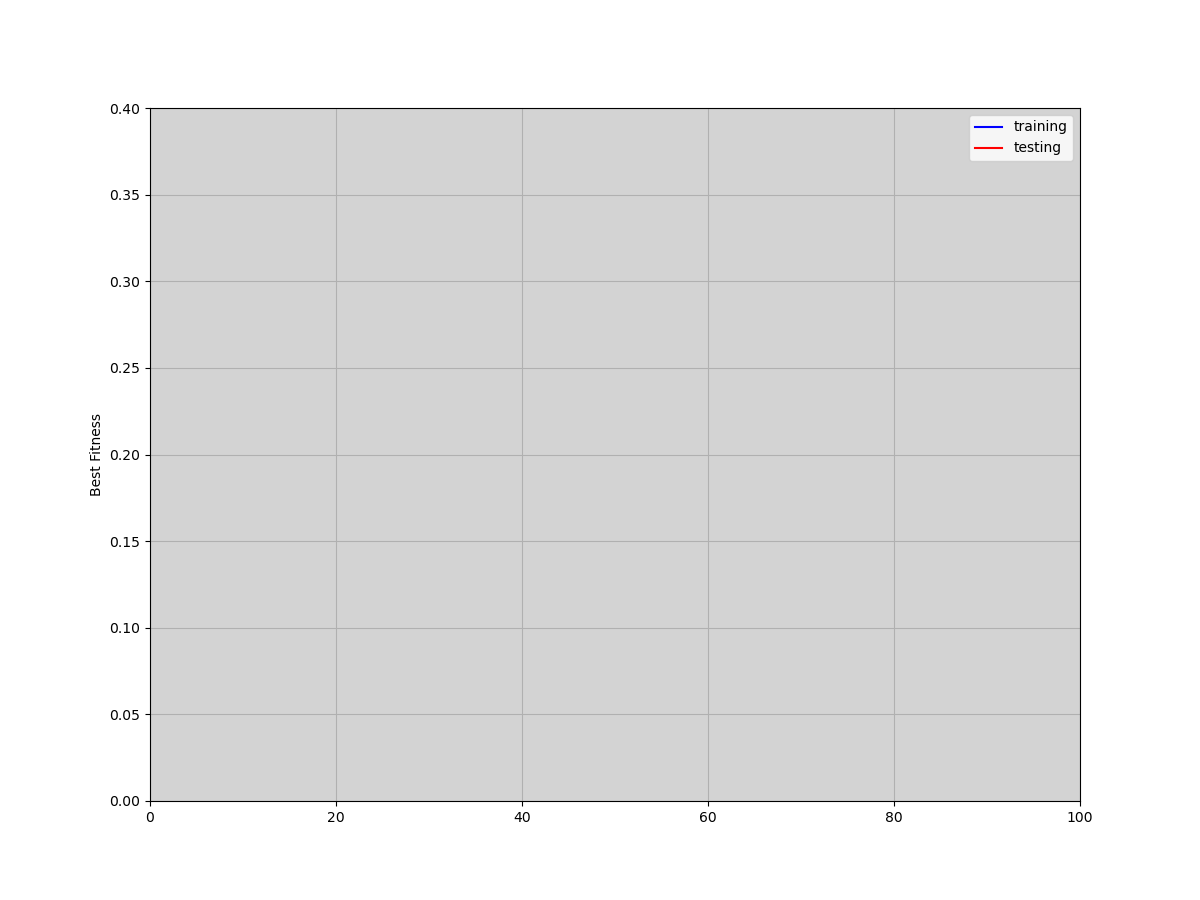

In [10]:
############################################################################################################
# The following piece of code, will allow us to display -in real time- the progress of training fitness,   #
# testing fitness and diversity decay. It is a bit overcomplicated, and it is optional of course, but it   #
# is very useful to understand and visualize if the GP is achieving convergence.                           #

x = list(range(Generations))                                                                               #

y = np.empty(Generations)                                                                                  #
y[:]=np.nan                                                                                                #
y2 = np.empty(Generations)                                                                                 #
y2[:]=np.nan                                                                                               #
d3 = np.empty(Generations)                                                                                 #
d3[:]=np.nan                                                                                               #

plt.ion()                                                                                                  #
fig = plt.figure(figsize=(12,9))                                                                                         #
ax = fig.add_subplot()                                                                                  # 
ax.set_ylabel('Best Fitness')                                                                              #
ax.set_ylim(0.0,0.4)                                                                                       #
ax.set_xlim(0,Generations)                                                                                 #
ax.set_facecolor('lightgray')                                                                              #  
ax.grid(True)                                                                                              #
#ax2 = fig.add_subplot(212)                                                                                 #
#ax2.set_xlabel('Generation')                                                                               #
#ax2.set_ylabel('Diversity')                                                                                #
#ax2.set_ylim(0.0,1.0)                                                                                      #
#ax2.set_xlim(0,Generations)                                                                                #
#ax2.set_facecolor('lightgray')                                                                             #
#ax2.grid(True)                                                                                             #

line1, = ax.plot(x, y, 'b-', label='training')                                                             #
line2, = ax.plot(x, y2, 'r-', label='testing')                                                             #
#line3, = ax2.plot(x, d3, 'y-')                                                                             #
ax.legend()                                                                                                #
############################################################################################################


In [11]:
pbar = tqdm.tqdm(total=Generations)                        

i = 0                          # Notice how now we need to manually count the number of generations elapsed 
for e in range(epochs):
    
    for j in range(no_batches):
        
        Population, d, bf, tf = Steady_StateMP(Population = Population,
                                               batch = batchesX[j],           # different minibatch each cycle
                                               labels = batchesY[j],
                                               test_batch = x_testing,
                                               test_labels = y_testing,
                                               l_rate = l_rate,
                                               oper = oper,
                                               oper_prob = oper_prob,
                                               oper_arity = oper_arity,
                                               minimization = minimization,
                                               sel_mechanism = sel_mechanism,
                                               online = True,
                                               pro=16)  
        
        diversity.append(d)
        fitness.append(bf)
        test_fitness.append(tf)

        # For live plotting #################
        y[i]=fitness[i]
        y2[i]=test_fitness[i]
        #d3[i]=diversity[i]

        line1.set_ydata(y)
        line2.set_ydata(y2)
        #line3.set_ydata(d3)

        fig.canvas.draw()
        #####################################
        
        i += 1
        pbar.update(1)      
    
pbar.close()

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [15:22<00:00,  9.23s/it]


We have achieved a better performance than the non online version, in just a fraction of the time. Let's corroborate the results:

In [12]:
print("Training fitness of best individual found: ", fitness[-1])
print("Testing  fitness of best individual found: ", test_fitness[-1])

Training fitness of best individual found:  0.03068665522392737
Testing  fitness of best individual found:  0.025587765428574865


The results are expressed in MSE, which is the error measure used by SimpleRegresor class.

Let's extract the best individual from the population in order to display its syntax tree.

In [ ]:
solver = elite_selection(population=Population, amount=1, minimization=minimization)[0]

Now, let's plot it and see how it sees...

In [ ]:
plt.figure(figsize=(7,7))
graph, labels, color_map = get_graph(solver.tree)
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=700, node_color=color_map)

Finally, let's see how does it look the curve that our models approximates, and compare it against the real function...

In [ ]:
x = np.arange(1000)
x = ((x / 1000) * 6.28) - 3.14
x = x.reshape(1000,1)

y = np.zeros(1000)
y2 = np.zeros(1000)

for i in range(1000):
    y[i] = solver.predict(x[i])
    y2[i] = np.sin(x[i])


fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.grid(True)

line1, = ax.plot(x, y, 'b-', label='Approximation')
line2, = ax.plot(x, y2, 'r-', label='Ground Truth')

ax.legend()
plt.show()

Online learning will -in general- speed up considerably the performance of GP. This is specially true for evolving models with rather big datasets (ten thousand samples and above). 

Another option to increase GP runs' speed, is to use the multiple CPUs/processing threads that are now available in most modern home, scientific and industrial computer systems. Even comercial desktop and laptop (and even SoC's) PCs have now at least 4 CPUs or processing threads. TurboGP supports the use of multiple CPUs. However, it is also important to focus on techniques such as online learning to achieve significant runtime gains.

The combined use of mini-batch learning and multiple CPUs requires to find a fine balance between the number of CPUs used, the size of the minibatches and the size of the population, if parallel algorithmic efficience is to be achieved. Next notebook will discuss in detail the usage of multiple CPUs with TurboGP.